# 03 — Challenger Benchmark: LightGBM vs Champion + SHAP

## Goal
Build a **Challenger** model (LightGBM) and compare it against the Champion (logistic) under a Model Risk framework:
- performance & calibration (Train vs OOT)
- score stability (PSI + KS Train→OOT)
- interpretability (SHAP global drivers + one local explanation)

**Decision principle:** a challenger should not win only on Train AUC; it must improve OOT performance and remain stable/defensible.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import TARGET_COL

from src.data.load_raw import load_raw_loans
from src.data.clean import filter_closed_loans_and_target
from src.data.features import add_credit_history_length
from src.data.split import time_split

from src.models.champion_logit import fit_champion, predict_pd as predict_champion_pd
from src.models.challenger_lgbm import build_challenger_pipeline, fit_challenger, predict_pd as predict_lgbm_pd

from src.validation.compare import model_summary_table, stability_summary
from src.validation.interpretability import shap_global_summary

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

## Data preparation

We reuse the same data governance rules:
- closed-outcome PD target only
- underwriting-safe features
- true out-of-time split

This ensures the challenger comparison is fair and reproducible.

In [2]:
df = load_raw_loans()
df = filter_closed_loans_and_target(df)
df = add_credit_history_length(df)

train, oot = time_split(df)

print("Train:", train.shape, "default rate:", train[TARGET_COL].mean())
print("OOT  :", oot.shape,   "default rate:", oot[TARGET_COL].mean())

Train: (1163294, 31) default rate: 0.20667260383015815
OOT  : (47191, 31) default rate: 0.14729503507024644


## Fit Champion (logistic)

Champion provides an interpretable baseline and a reference for:
- OOT performance
- calibration drift
- monitoring artifacts

In [3]:
champ_pipe, kept_num, kept_cat, dropped = fit_champion(train)

train_ch = train.copy()
oot_ch = oot.copy()
train_ch["pd_pred"] = predict_champion_pd(champ_pipe, train_ch, kept_num, kept_cat)
oot_ch["pd_pred"] = predict_champion_pd(champ_pipe, oot_ch, kept_num, kept_cat)

print("Kept numeric:", kept_num)
print("Kept categorical:", kept_cat)
print("Dropped numeric:", dropped["dropped_num"])
print("Dropped categorical:", dropped["dropped_cat"])

Kept numeric: ['annual_inc', 'dti', 'int_rate', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'installment', 'funded_amnt', 'loan_amnt', 'credit_history_length_years']
Kept categorical: ['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'application_type']
Dropped numeric: []
Dropped categorical: []


## Fit Challenger (LightGBM)

To make the comparison fair:
- we train the challenger on the **same kept features** as the Champion (governance + missingness policy)
- we use conservative LightGBM hyperparameters (avoid obvious overfit)

In [4]:
lgbm_pipe = build_challenger_pipeline(kept_num, kept_cat)
lgbm_pipe = fit_challenger(lgbm_pipe, train, TARGET_COL, kept_num, kept_cat)

train_lb = train.copy()
oot_lb = oot.copy()
train_lb["pd_pred"] = predict_lgbm_pd(lgbm_pipe, train_lb, kept_num, kept_cat)
oot_lb["pd_pred"] = predict_lgbm_pd(lgbm_pipe, oot_lb, kept_num, kept_cat)

[LightGBM] [Info] Number of positive: 240421, number of negative: 922873
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020902 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2632
[LightGBM] [Info] Number of data points in the train set: 1163294, number of used features: 91
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.206673 -> initscore=-1.345100
[LightGBM] [Info] Start training from score -1.345100


/Users/noelp/PycharmProjects/model-risk-validation-pd-lgd-ead/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/noelp/PycharmProjects/model-risk-validation-pd-lgd-ead/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Performance + calibration (Train vs OOT)

We compare:
- discrimination: AUC / KS / PR-AUC / Top10% capture
- probability quality: Brier + calibration slope/intercept
- probability level: Mean_PD vs observed default rate

In [5]:
summ_ch = model_summary_table(
    "Champion_Logit",
    train[TARGET_COL].values, train_ch["pd_pred"].values,
    oot[TARGET_COL].values, oot_ch["pd_pred"].values
)

summ_lb = model_summary_table(
    "Challenger_LGBM",
    train[TARGET_COL].values, train_lb["pd_pred"].values,
    oot[TARGET_COL].values, oot_lb["pd_pred"].values
)

summary = pd.concat([summ_ch, summ_lb], ignore_index=True)
summary

,model,set,AUC,PR_AUC,Gini,KS,Brier,Top10pct_Default_Capture,Mean_PD,Obs_Default_Rate,Calib_Intercept,Calib_Slope
0,Champion_Logit,Train,0.710398,0.382390,0.420796,0.304751,0.148541,0.225242,0.206689,0.206673,-0.000548,0.999630
1,Champion_Logit,OOT,0.697331,0.263056,0.394662,0.293866,0.121314,0.209179,0.190617,0.147295,-0.541985,0.836992
2,Challenger_LGBM,Train,0.731772,0.415546,0.463544,0.336780,0.144831,0.242134,0.206674,0.206673,0.091496,1.078995
3,Challenger_LGBM,OOT,0.726237,0.303842,0.452473,0.337220,0.118278,0.241116,0.196845,0.147295,-0.418515,0.973870


In [6]:
# Pivot for easier reading
pivot = summary.pivot(index="set", columns="model")
pivot

AUC                         PR_AUC                 \
model Challenger_LGBM Champion_Logit Challenger_LGBM Champion_Logit   
set                                                                   
OOT          0.726237       0.697331        0.303842       0.263056   
Train        0.731772       0.710398        0.415546       0.382390   

                 Gini                             KS                 \
model Challenger_LGBM Champion_Logit Challenger_LGBM Champion_Logit   
set                                                                   
OOT          0.452473       0.394662         0.33722       0.293866   
Train        0.463544       0.420796         0.33678       0.304751   

                Brier                Top10pct_Default_Capture                 \
model Challenger_LGBM Champion_Logit          Challenger_LGBM Champion_Logit   
set                                                                            
OOT          0.118278       0.121314                 0.241116       0.209179   
Train        0.144831       0.148541                 0.242134       0.225242   

              Mean_PD                Obs_Default_Rate                 \
model Challenger_LGBM Champion_Logit  Challenger_LGBM Champion_Logit   
set                                                                    
OOT          0.196845       0.190617         0.147295       0.147295   
Train        0.206674       0.206689         0.206673       0.206673   

      Calib_Intercept                    Calib_Slope                 
model Challenger_LGBM Champion_Logit Challenger_LGBM Champion_Logit  
set                                                                  
OOT         -0.418515      -0.541985        0.973870       0.836992  
Train        0.091496      -0.000548        1.078995       0.999630

**Interpretation guide**
- A challenger is compelling if it improves OOT discrimination (AUC/PR-AUC/KS) without harming calibration and stability.
- Large Train gains with no OOT gains usually indicate overfit.

**Key comparison (OOT)**
- The challenger improves OOT discrimination materially (higher AUC, KS, and PR-AUC).
- Calibration is also improved OOT: slope is closer to 1 and intercept is less negative than the champion.
- Both models still overpredict the OOT base rate (Mean_PD > observed default rate), consistent with population drift; challenger reduces this miscalibration.

## Score stability (Train→OOT)

We compare score stability via:
- score PSI (distribution drift magnitude)
- two-sample KS statistic (distribution drift effect size)

Lower drift is generally preferred for production stability.

In [7]:
stab_ch = stability_summary("Champion_Logit", train_ch, oot_ch, kept_num, kept_cat, score_col="pd_pred")
stab_lb = stability_summary("Challenger_LGBM", train_lb, oot_lb, kept_num, kept_cat, score_col="pd_pred")

stab = pd.DataFrame([stab_ch, stab_lb])
stab

,model,score_psi,score_ks_stat,score_ks_p
0,Champion_Logit,0.025877,0.057605,2.986697e-131
1,Challenger_LGBM,0.015908,0.044408,3.732433e-78


**Stability takeaway**

The challenger score distribution shifts less from Train → OOT (lower score PSI and lower two-sample KS effect size),
which is preferable for production stability and monitoring.

## Interpretability: SHAP global drivers (Challenger)

We use SHAP to:
- understand the global risk drivers of the challenger
- check face validity (do drivers align with credit intuition?)
- detect suspicious dependence patterns (potential proxy leakage or spurious artifacts)

We compute SHAP on a subsample for speed.

In [8]:
import shap
import matplotlib.pyplot as plt

X_oot = oot_lb[kept_num + kept_cat]

shap_vals, feat_names, X_trans = shap_global_summary(lgbm_pipe, X_oot, max_samples=20000)
print("SHAP matrix shape:", shap_vals.shape, " | features:", len(feat_names))

SHAP matrix shape: (20000, 93)  | features: 93


/Users/noelp/PycharmProjects/model-risk-validation-pd-lgd-ead/.venv/lib/python3.13/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


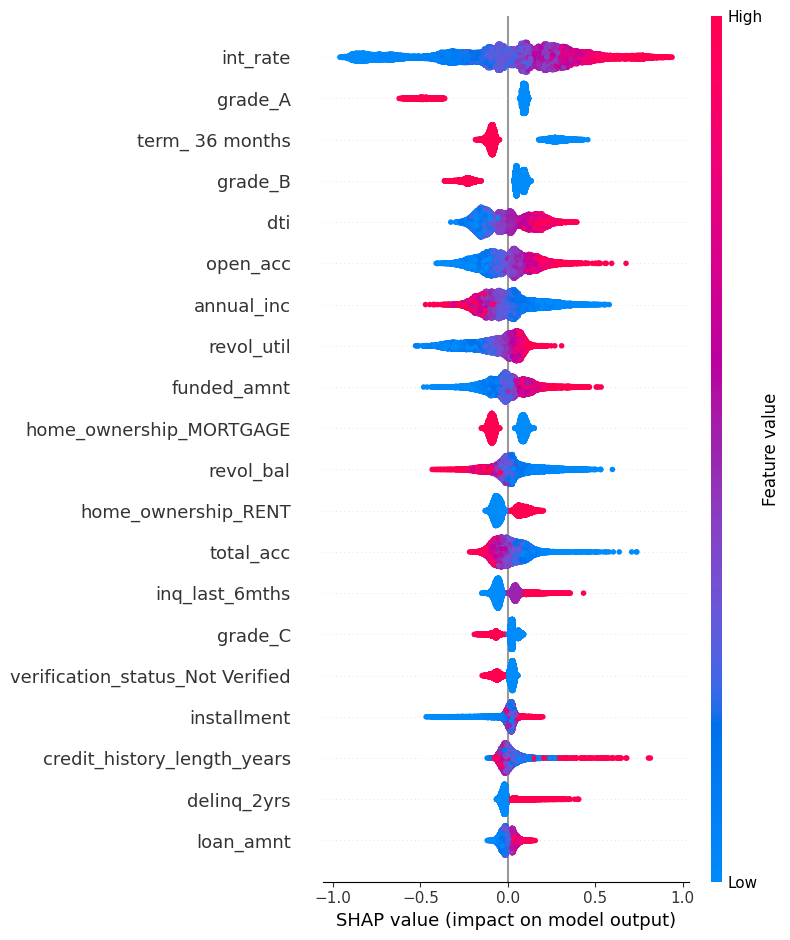

In [9]:
# Global beeswarm plot (top drivers)
shap.summary_plot(shap_vals, X_trans, feature_names=feat_names, show=True)

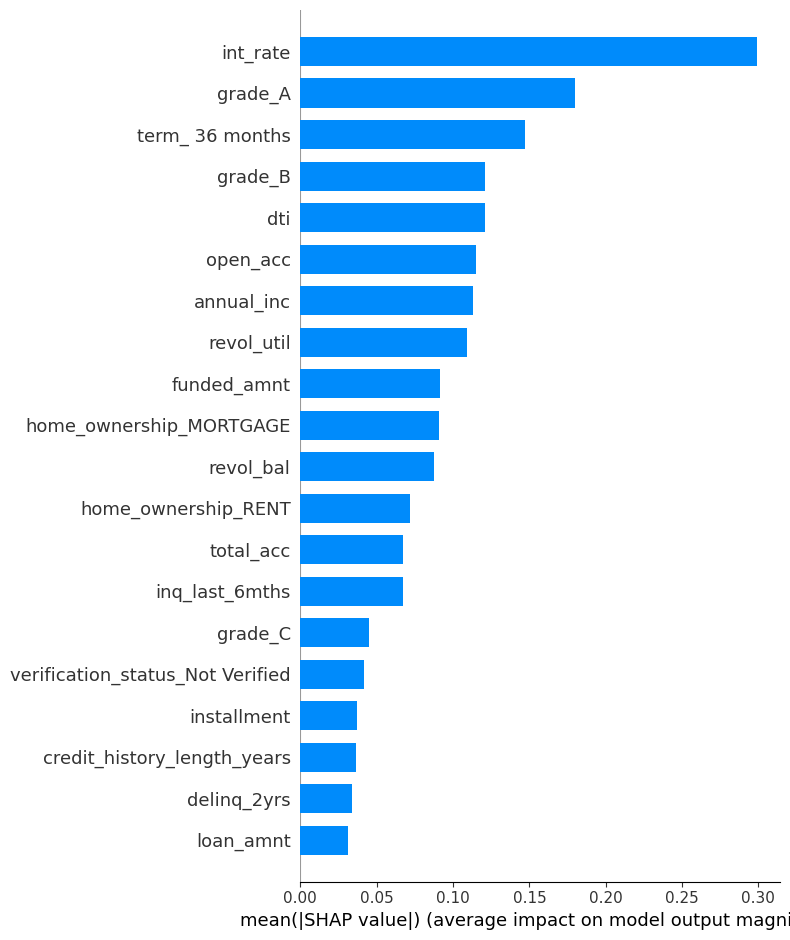

In [10]:
# Optional: bar plot of mean(|SHAP|) as a report-friendly summary
shap.summary_plot(shap_vals, X_trans, feature_names=feat_names, plot_type="bar", show=True)

**What to look for**
- Do top drivers make credit sense? (DTI, interest rate, utilization, grade/sub_grade, term, etc.)
- Are there suspicious “post-outcome” style fields? (should not exist in the allowed feature list)
- Is the model overly dominated by one feature? (fragility risk)

**SHAP sanity check**

Top global drivers (interest rate, grade, term, DTI, utilization, income) align with credit intuition.
No post-origination leakage-type fields appear among the top drivers, supporting model governance compliance.

## Local explanation (waterfall) for one example

A single-case explanation helps validate:
- directionality of effects (risk increasing vs decreasing)
- human plausibility for a typical borrower

We pick one high-risk and one low-risk example.

In [16]:
# Choose representative low-risk and high-risk cases using percentiles (avoid extreme outliers)
q_low, q_high = 0.05, 0.95

low_thr = oot_lb["pd_pred"].quantile(q_low)
high_thr = oot_lb["pd_pred"].quantile(q_high)

# Pick one example closest to each threshold
low_idx = (oot_lb["pd_pred"] - low_thr).abs().idxmin()
high_idx = (oot_lb["pd_pred"] - high_thr).abs().idxmin()

low_case = oot_lb.loc[[low_idx], kept_num + kept_cat]
high_case = oot_lb.loc[[high_idx], kept_num + kept_cat]

low_pd = float(oot_lb.loc[low_idx, "pd_pred"])
high_pd = float(oot_lb.loc[high_idx, "pd_pred"])

print(f"Low-risk (~p{int(q_low*100)}) PD:", low_pd)
print(f"High-risk (~p{int(q_high*100)}) PD:", high_pd)

Low-risk (~p5) PD: 0.03446010290363638
High-risk (~p95) PD: 0.4546968434655933


/Users/noelp/PycharmProjects/model-risk-validation-pd-lgd-ead/.venv/lib/python3.13/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


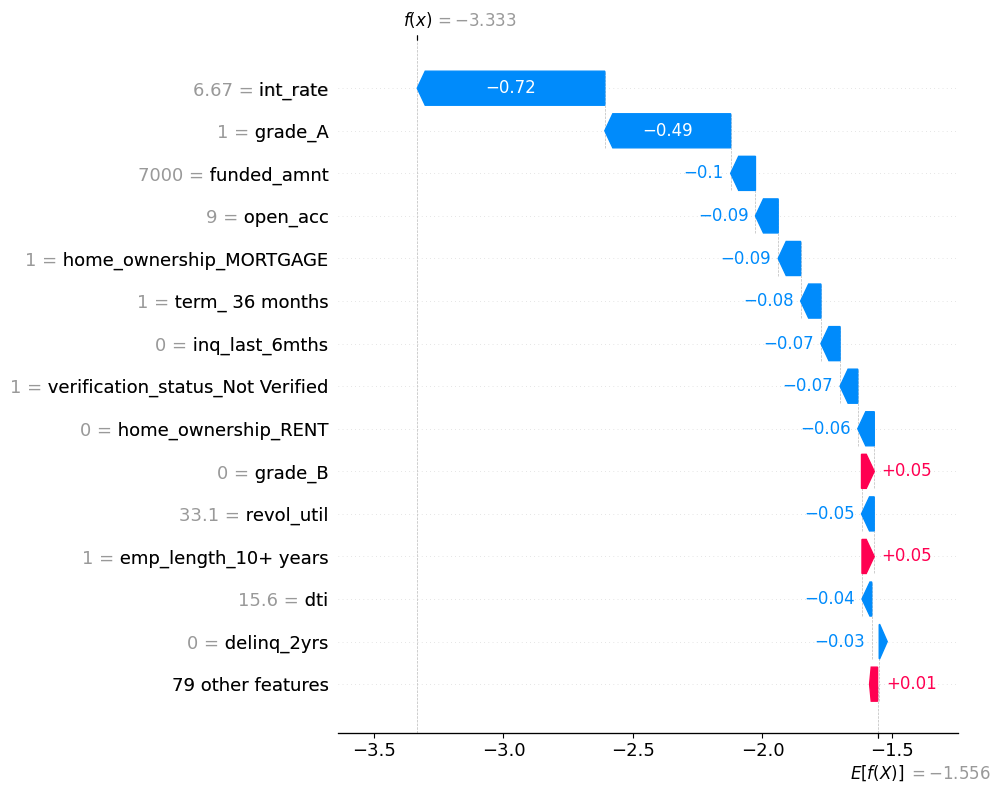

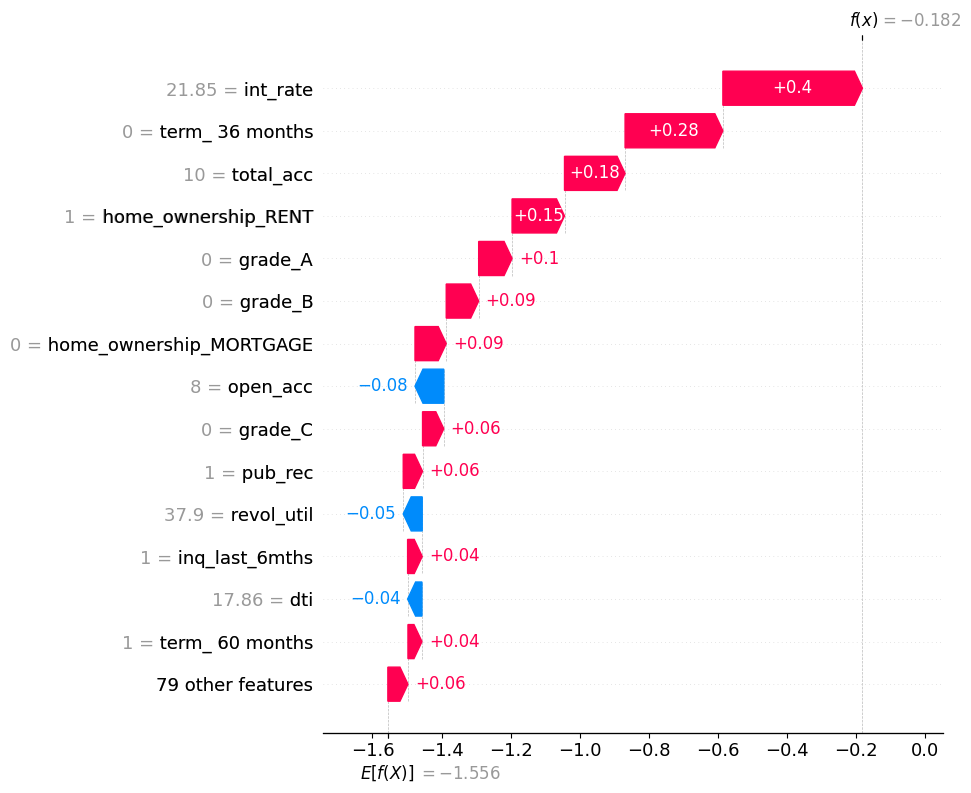

In [17]:
# Build SHAP Explanation objects for waterfall plots
pre = lgbm_pipe.named_steps["preprocess"]
model = lgbm_pipe.named_steps["model"]

X_low = pre.transform(low_case)
X_high = pre.transform(high_case)

explainer = shap.TreeExplainer(model)

sv_low = explainer.shap_values(X_low)
sv_high = explainer.shap_values(X_high)

if isinstance(sv_low, list):
    sv_low = sv_low[1]
    sv_high = sv_high[1]

base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[1]

exp_low = shap.Explanation(values=sv_low[0], base_values=base_value, data=X_low[0], feature_names=pre.get_feature_names_out())
exp_high = shap.Explanation(values=sv_high[0], base_values=base_value, data=X_high[0], feature_names=pre.get_feature_names_out())

shap.plots.waterfall(exp_low, max_display=15, show=True)
shap.plots.waterfall(exp_high, max_display=15, show=True)

**Local explanation sanity check**

The low-risk case (~p5) is driven by low interest rate, top grade, and shorter term, pushing risk down.

The high-risk case (~p95) is driven by high interest rate, longer term, and renting status, pushing risk up.

This aligns with credit intuition and supports face validity of the challenger.

# Decision: Challenger vs Champion (evidence-based)

## Recommendation
**Challenger_LGBM is a strong candidate for promotion** (subject to governance checks and calibration policy),
because it improves **OOT discrimination**, improves **OOT calibration**, and shows **lower score drift**.

## Evidence (OOT)
- Discrimination improved: AUC (0.726 vs 0.697), PR-AUC (0.304 vs 0.263), KS (0.337 vs 0.294).
- Calibration improved: slope closer to 1 (0.974 vs 0.837) and less negative intercept (-0.419 vs -0.542).
- Stability improved: lower score PSI (0.016 vs 0.026) and lower score KS shift (0.044 vs 0.058).

## Residual model risk
- Both models overpredict the OOT base rate (Mean_PD > observed default rate), consistent with population drift.
- Promotion should include a monitoring + recalibration plan (calibration-in-the-large, slope, PSI thresholds).

## Governance next steps
- Run the same drift/sensitivity/stress suite on challenger outputs (Notebook 02 framework) and set monitoring triggers.
- Define a recalibration cadence (e.g., annual) if PD levels deviate materially from observed defaults.

In [13]:
# Quick comparison snippet for the report narrative
oot_comp = summary[summary["set"] == "OOT"].copy().set_index("model")
oot_comp[["AUC", "PR_AUC", "KS", "Brier", "Mean_PD", "Obs_Default_Rate", "Calib_Intercept", "Calib_Slope"]]

,AUC,PR_AUC,KS,Brier,Mean_PD,Obs_Default_Rate,Calib_Intercept,Calib_Slope
model,,,,,,,,
Champion_Logit,0.697331,0.263056,0.293866,0.121314,0.190617,0.147295,-0.541985,0.836992
Challenger_LGBM,0.726237,0.303842,0.337220,0.118278,0.196845,0.147295,-0.418515,0.973870
